# MatPlotLib Basics

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [90]:
x=[1,2,3,4,5,6,7,8,9,10]
y=[1,4,9,16,25,36,49,64,81,100]

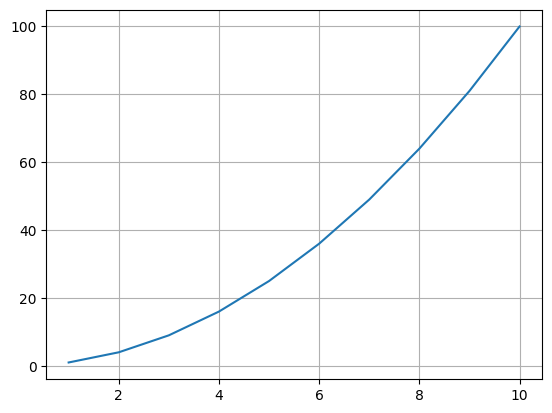

In [91]:
# Plotting a graph using list of values of x and y
plt.plot(x,y)
plt.grid()  # To show the gridlines
plt.show()

<h2> Pyplot API

<h3>Numerical Data Univariate Analysis

In [92]:
data={
    "salary":[10000,20400,30070,36000,50500,61800,80000,89600,99000,103300]
}

In [93]:
df=pd.DataFrame(data)
df.head()

,salary
0,10000
1,20400
2,30070
3,36000
4,50500


In [94]:
df.shape

(10, 1)

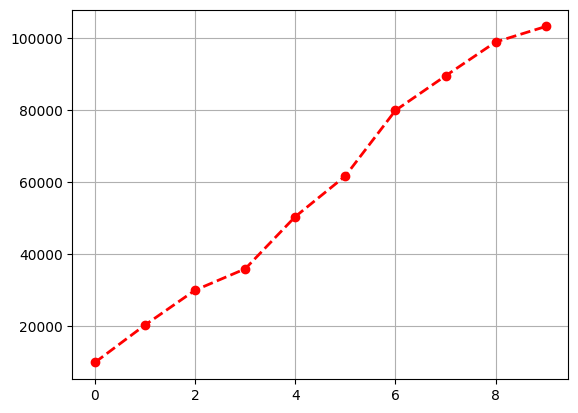

In [95]:
# Line Plot
plt.plot(df['salary'], color='red', marker='o', linestyle='--', linewidth=2)
plt.grid()
plt.show()

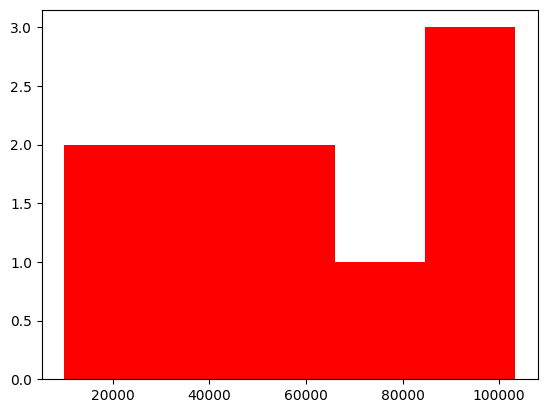

In [ ]:
# Histogram
plt.hist(df['salary'], bins=5, color='red')
plt.show()

# While plotting Histograms, if the data is skewed, then we can use the log scale to better visualize the data.
# log parameter -> (Boolean) It is used to set the scale of the axes to logarithmic. If True, then the scale of the axes will be logarithmic.
# plt.hist(df['salary'], bins=5, color='red', log=True)
# plt.show()

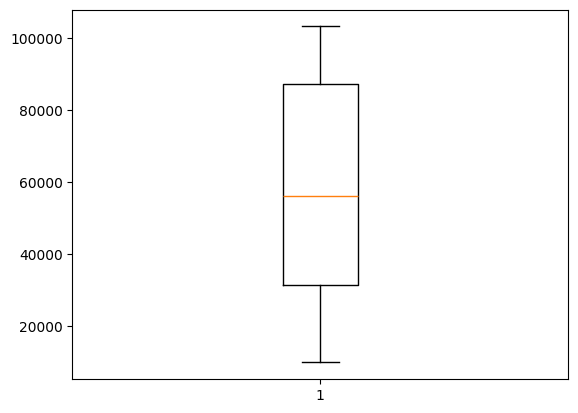

In [97]:
# Boxplot
plt.boxplot(df['salary'])
plt.show()

<h3>Categorical Data Univariate Analysis

In [98]:
df['dept']=['HR', 'Finance', 'IT', 'Finance', 'HR', 'IT', 'Finance', 'HR', 'IT', 'IT']

In [99]:
df.head()

,salary,dept
0,10000,HR
1,20400,Finance
2,30070,IT
3,36000,Finance
4,50500,HR


In [100]:
# Counting no. of different departments
count=df['dept'].value_counts()
count

dept
IT         4
HR         3
Finance    3
Name: count, dtype: int64

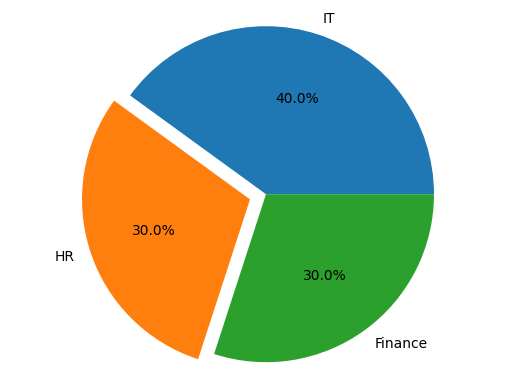

In [101]:
# Pie Chart
plt.pie(count, labels=count.index, autopct='%1.1f%%', explode=[0,0.1,0])
plt.axis('equal')
plt.show()

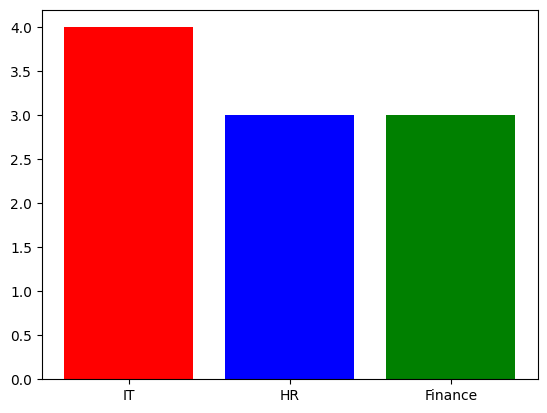

In [102]:
# CountPlot / BarPlot
plt.bar(count.index, count.values, color=['red', 'blue', 'green'])
plt.show()

<h3>Bivariate Analysis (Numerical-Numerical)

In [103]:
df['age']=[25,30,22,28,35,40,27,32,29,31]
df.head()

,salary,dept,age
0,10000,HR,25
1,20400,Finance,30
2,30070,IT,22
3,36000,Finance,28
4,50500,HR,35


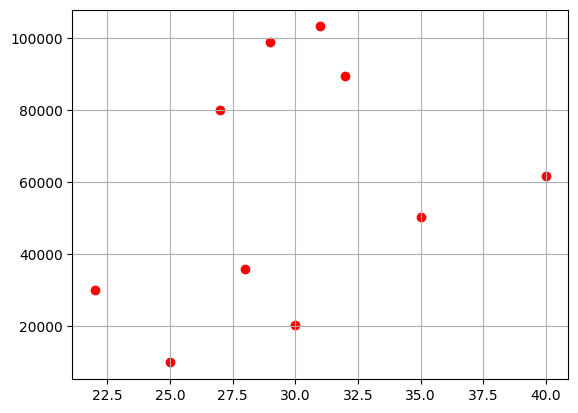

In [104]:
# Scatter Plot
plt.scatter(df['age'], df['salary'], color='red')
plt.grid()
plt.show()

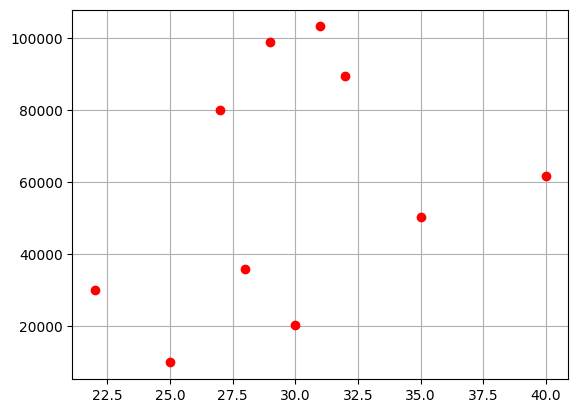

In [105]:
# Scatter Plot using plt.plot()
plt.plot(df['age'], df['salary'], color='red', marker='o', linestyle='None')
plt.grid()
plt.show()

# This method can also be used to create Scatter Plots.
# This method is faster, so it is useful for working with large datasets.
# But, the plt.scatter() method provides more options for customizing the appearance of the points, such as changing the size and color of the points based on additional variables in the dataset.

In [106]:
# Sorting the ages
sort=df.sort_values('age')

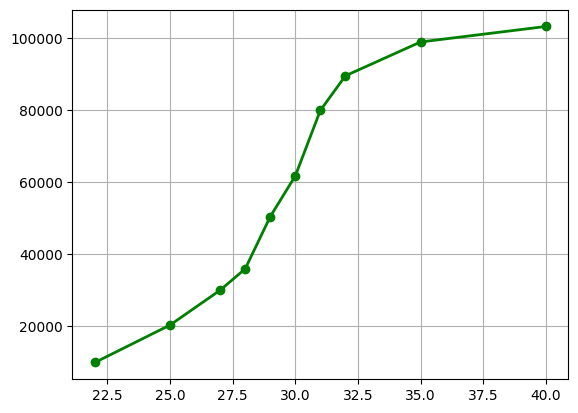

In [107]:
# Line Plot
plt.plot(sort['age'], df['salary'], color='green', marker='o', linestyle='-', linewidth=2)  # sort['age'] is passed instead of df['age'] to make it a visually understandable plot
plt.grid()
plt.show()

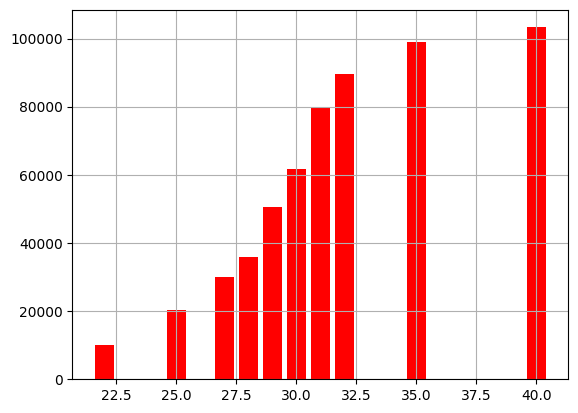

In [108]:
# Bar Chart
plt.bar(sort['age'], df['salary'], color='red', align='center')
plt.grid()
plt.show()

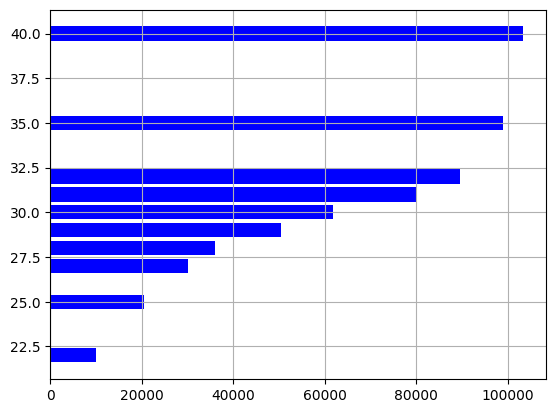

In [ ]:
# Horizontal bar chart
plt.barh(sort['age'], df['salary'], color='blue', align='center')
plt.grid()
plt.show()

# Useful when we have a large number of categories and we want to display the data in a more compact way.

<h3>Bivariate Analysis (Numerical-Categorical)

In [110]:
it_sal=df[df['dept']=='IT']['salary']
it_sal

2     30070
5     61800
8     99000
9    103300
Name: salary, dtype: int64

In [111]:
hr_sal=df[df['dept']=='HR']['salary']
hr_sal

0    10000
4    50500
7    89600
Name: salary, dtype: int64

In [112]:
fin_sal=df[df['dept']=='Finance']['salary']
fin_sal

1    20400
3    36000
6    80000
Name: salary, dtype: int64

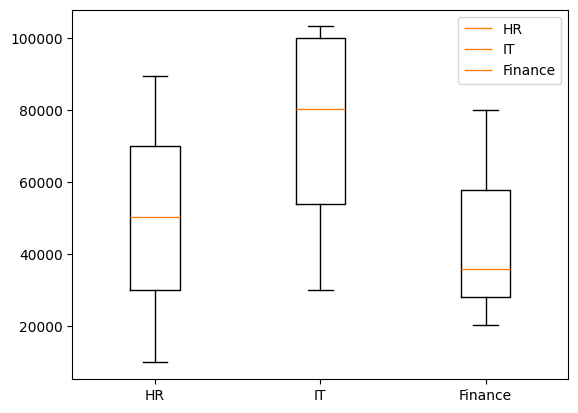

In [113]:
# BoxPlot
plt.boxplot([hr_sal, it_sal, fin_sal], label=['HR', 'IT', 'Finance'], tick_labels=['HR', 'IT', 'Finance'])
plt.legend()
plt.show()

In [114]:
sal_by_dept=df.groupby('dept')['salary'].sum()
sal_by_dept

dept
Finance    136400
HR         150100
IT         294170
Name: salary, dtype: int64

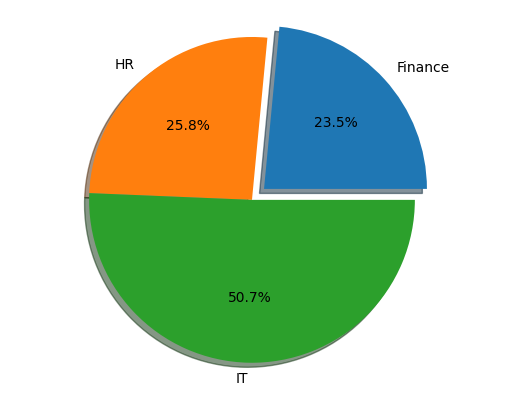

In [115]:
# Pie Chart
plt.pie(sal_by_dept.values, labels=sal_by_dept.index, autopct='%1.1f%%', shadow=True, explode=[0.1,0,0])
plt.axis('equal')
plt.show()

In [116]:
hr_mean_sal=sum(hr_sal)/len(hr_sal)
it_mean_sal=sum(it_sal)/len(it_sal)
fin_mean_sal=sum(fin_sal)/len(fin_sal)

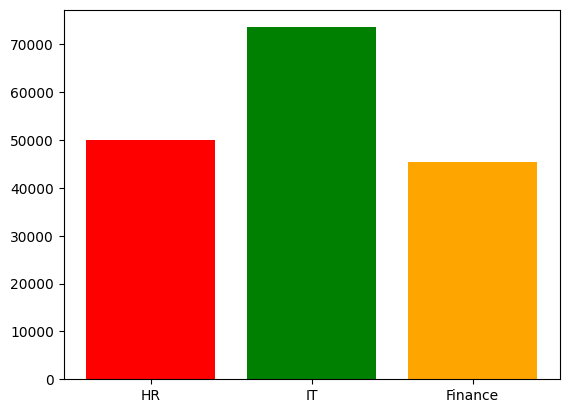

In [117]:
# Bar Chart
plt.bar(['HR', 'IT', 'Finance'], [hr_mean_sal, it_mean_sal, fin_mean_sal], color=['red', 'green', 'orange'])
plt.show()

<h4>Now, we can also display multiple graphs on a single plot. <br>
Matplotlib does not have a built-in function for that, so we have to use some tricks to make the desired plot.

In [129]:
cricket={
    'Name': ['AB De Villiers', 'DA Warner', 'MS Dhoni', 'Virat Kohli', 'Rohit Sharma'],
    '2015': [500, 600, 400, 700, 550],
    '2016': [550, 650, 450, 750, 600],
    '2017': [600, 700, 500, 800, 650]
}

cricdf=pd.DataFrame(cricket)
cricdf

,Name,2015,2016,2017
0,AB De Villiers,500,550,600
1,DA Warner,600,650,700
2,MS Dhoni,400,450,500
3,Virat Kohli,700,750,800
4,Rohit Sharma,550,600,650


In [132]:
n=np.arange(cricdf.shape[0])
n

array([0, 1, 2, 3, 4])

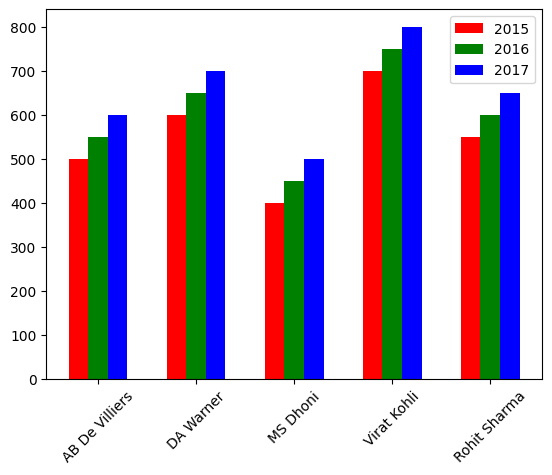

In [ ]:
# a number is added/subtracted to the n values to create a gap between the bars of different years for better visualization
plt.bar(n-0.2, cricdf['2015'], width=0.2, color='red', label='2015')
plt.bar(n, cricdf['2016'], width=0.2, color='green', label='2016')
plt.bar(n+0.2, cricdf['2017'], width=0.2, color='blue', label='2017')
plt.xticks(n, cricdf['Name'], rotation=45)      # To set the x-ticks to the names of the players and rotate them by 45 degrees for better visibility
plt.legend()
plt.show()

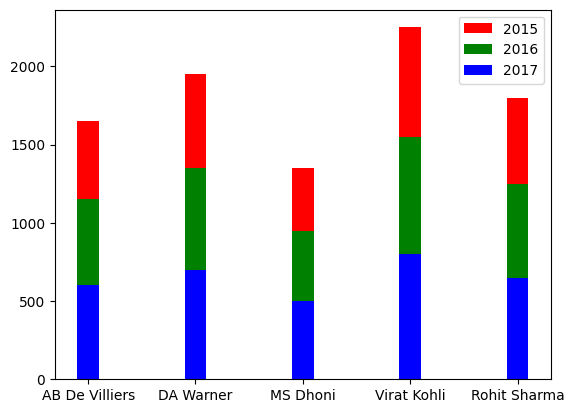

In [ ]:
# Stacked Bar Chart
plt.bar(cricdf['Name'], cricdf['2015'], width=0.2, color='red', bottom=(cricdf['2016']+cricdf['2017']), label='2015')
plt.bar(cricdf['Name'], cricdf['2016'], width=0.2, color='green', bottom=cricdf['2017'], label='2016')
plt.bar(cricdf['Name'], cricdf['2017'], width=0.2, color='blue', label='2017')
plt.legend()
plt.show()

# This chart shows the total runs scored by each player in each year, while retaining the individual contributions of each year.
# It allows us to compare the performance of the players across different years and also see the overall trend in their performance over time. 

# 'bottom' parameter ->     It is used to specify the starting point of the bars in a stacked bar chart. 
#                           It takes an array of values that represent the cumulative height of the bars below the current bar. 
#                           This allows us to stack the bars on top of each other, creating a visual representation of the total value for each category while also showing the individual contributions of each sub-category.

<h3>Multivariate Analysis (3 numerical Columns)

In [118]:
df['experience']=[2,5,1,4,6,8,3,7,4,5]
df.head()

,salary,dept,age,experience
0,10000,HR,25,2
1,20400,Finance,30,5
2,30070,IT,22,1
3,36000,Finance,28,4
4,50500,HR,35,6


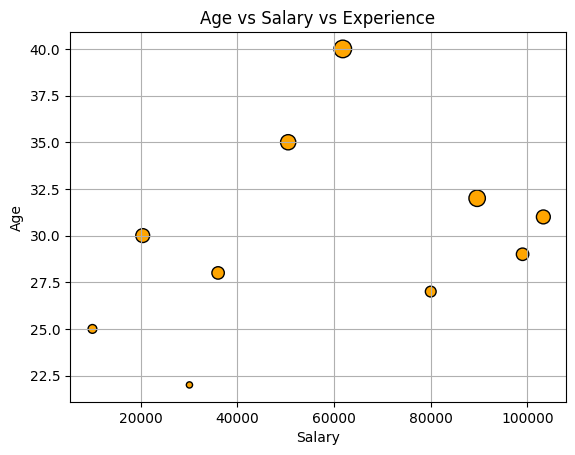

In [119]:
# Bubble Plot

plt.scatter(df['salary'], df['age'], s=df['experience']*20, color='orange', edgecolor='black')      # 's' determines the size of the bubble. 
                                                                                                    # Here, it is multiplied by 20 to give a better visualization effect.
plt.title("Age vs Salary vs Experience")
plt.xlabel("Salary")
plt.ylabel("Age")
plt.grid()
plt.show()

<h3>Multivariate Analysis (2 numerical, 1 categorical)

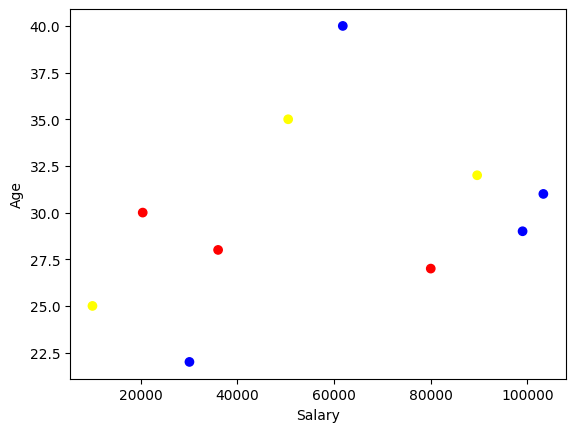

In [120]:
# Scatter Plot
plt.scatter(df['salary'], df['age'], c=df['dept'].map({"HR": 'yellow', "IT": 'blue', "Finance": 'red'}))
plt.xlabel("Salary")
plt.ylabel("Age")
plt.show()

# Object Oriented API

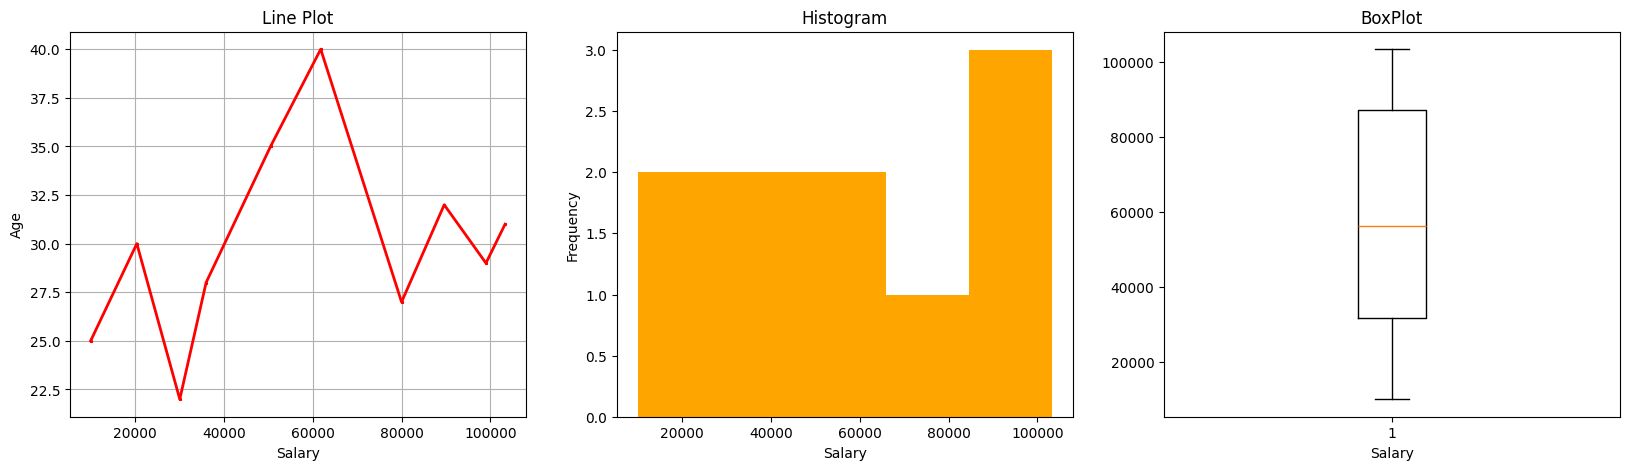

In [79]:
fig, axes= plt.subplots(1,3, figsize=(20,5))     # This basically creates 1 plot and 3 subplots, with size 10x5

# 1st plot: Line Plot
axes[0].plot(df['salary'], df['age'], color='red', marker="*", linewidth=2, markersize=2)
axes[0].grid()
axes[0].set_title("Line Plot")
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Age")

# 2nd plot: Histogram
axes[1].hist(df['salary'], bins=5, color='orange')
axes[1].set_title("Histogram")
axes[1].set_xlabel("Salary")
axes[1].set_ylabel("Frequency")

# 3rd plot: Boxplot
axes[2].boxplot(df['salary'])
axes[2].set_title("BoxPlot")
axes[2].set_xlabel("Salary")

# Saving a figure
plt.savefig("MultiPlots.png")

plt.show()

<h3>Multiple plots in a single graph

In [80]:
data2={
    'Years': [2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'Sales': [100, 250, 200, 180, 300, 270, 500],
    'Profit': [20, 40, 30, 28, 50, 34, 1000],
    'Expenses': [80, 120, 140, 300, 280, 220, 840]
}

df=pd.DataFrame(data2)
df

,Years,Sales,Profit,Expenses
0,2020,100,20,80
1,2021,250,40,120
2,2022,200,30,140
3,2023,180,28,300
4,2024,300,50,280
5,2025,270,34,220
6,2026,500,1000,840


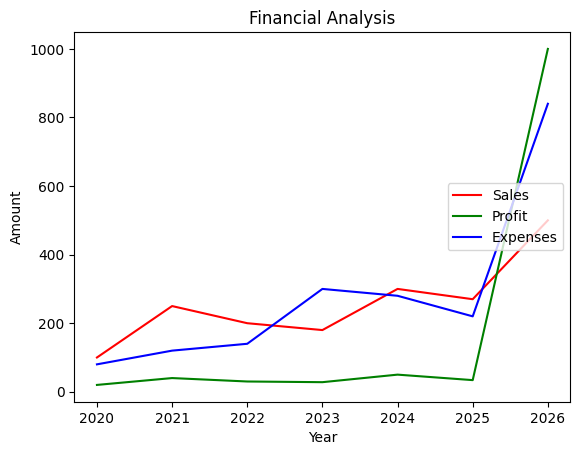

In [81]:
plt.plot(df['Years'], df['Sales'], color='red', label='Sales')
plt.plot(df['Years'], df['Profit'], color='green', label='Profit')
plt.plot(df['Years'], df['Expenses'], color='blue', label='Expenses')

plt.title("Financial Analysis")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend(loc="right") 
# loc parameter (optional) -> used to specify the location of the legend. 
# It can take values like 'upper right', 'upper left', 'lower right', 'lower left', 'center right', 'center left', 'upper center', 'lower center', 'right', 'center', 'best'.
# By default, it is "best", which means that the legend will be placed in the location that is least likely to overlap with the data points.
plt.show()

(0.0, 300.0)

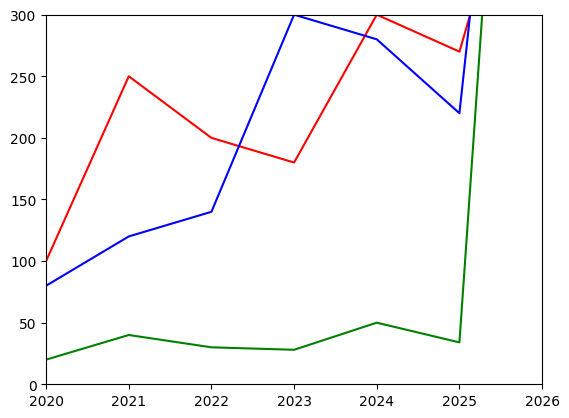

In [82]:
# Now, if there are any outlier values in the dataset (like in the above graph), then we can put a limit on any of the axes to limit the range of values that are displayed on the graph.
# This can help to improve the visualization and make it easier to interpret the data.
plt.plot(df['Years'], df['Sales'], color='red', label='Sales')
plt.plot(df['Years'], df['Profit'], color='green', label='Profit')
plt.plot(df['Years'], df['Expenses'], color='blue', label='Expenses')
plt.xlim(2020, 2026)   # This will set the limit of x-axis from 2020 to 2026
plt.ylim(0, 300)      # This will set the limit of y-axis from 0 to 100

# 3-D Plot

In [83]:
df

,Years,Sales,Profit,Expenses
0,2020,100,20,80
1,2021,250,40,120
2,2022,200,30,140
3,2023,180,28,300
4,2024,300,50,280
5,2025,270,34,220
6,2026,500,1000,840


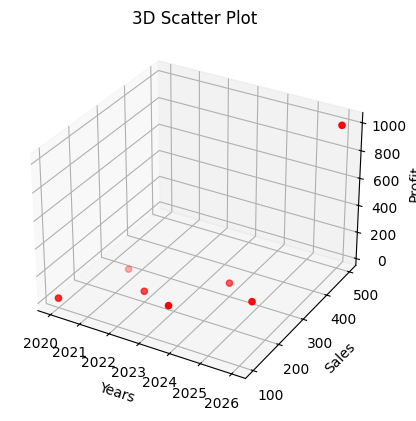

In [84]:
fig=plt.axes(projection='3d')

fig.scatter(df['Years'], df['Sales'], df['Profit'], color='red')
fig.set_title("3D Scatter Plot")
fig.set_xlabel("Years")
fig.set_ylabel("Sales")
fig.set_zlabel("Profit")
plt.show()

# 3-d Plot using Plotly

In [85]:
import plotly.express as px

fig=px.scatter_3d(df, x='Years', y='Sales', z='Profit', color='Expenses', title="3D Scatter Plot with Plotly")
fig.show()

# Most Common Use Cases

2D Line-Plot: <br>

- Bivariate analysis
- Numerical-Numerical or Categorical-Numerical Data
- Time Series Data

Scatter Plots: <br>

- Bivariate analysis
- Numerical-Numerical Data
- Finding Correlation

Histogram: <br>

- Univariate analysis
- Numerical Data
- Frequency Count

Pie Charts: <br>

- Univariate/Bivariate analysis
- Categorical-Numerical Data
- To find Contribution on a Standard Scale

# Changing Styles

In [141]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [ ]:
# plt.style.use('StyleName')

# This is used to set the style of the plots. Matplotlib provides several built-in styles that can be used to change the appearance of the plots.